# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [ ]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# titanic = pd.read_csv("../datasets/titanic.csv")
# wine = pd.read_csv("../datasets/wine.csv")
# bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

# print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [ ]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum()

    report = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(frame) * 100).round(2)
    })

    report = report[report["missing"] > 0]
    report = report.sort_values("missing", ascending=False)

    return report

In [ ]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [ ]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(sort_column, ascending=False)

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [ ]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [ ]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    result = frame.copy()

    group_medians = result.groupby(["Pclass", "Sex"])["Age"].transform("median")

    result.loc[result["Age"].isna(), "Age"] = group_medians[result["Age"].isna()]

    return result

In [ ]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [ ]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    # Original column
    s = frame[column]

    # 1. Drop missing values
    dropna_values = s.dropna()

    # 2. Fill with the overall mean
    mean_values = s.fillna(s.mean())

    # 3. Fill with the overall median
    median_values = s.fillna(s.median())

    # 4. Fill with median of each (Pclass, Sex) group
    group_medians = frame.groupby(["Pclass", "Sex"])[column].transform("median")
    group_values = s.fillna(group_medians)

    results = {
        "dropna": dropna_values,
        "mean": mean_values,
        "median": median_values,
        "group_median": group_values
    }

    rows = []

    for name in ["dropna", "mean", "median", "group_median"]:
        values = results[name]

        rows.append({
            "n": values.notna().sum(),
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std()
        })

    return pd.DataFrame(
        rows,
        index=["dropna", "mean", "median", "group_median"]
    )

In [ ]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

In [ ]:
print(_comparison)

print("\nDifference in standard deviation:")
print(
    "dropna std:",
    _comparison.loc["dropna", "std"]
)
print(
    "mean imputation std:",
    _comparison.loc["mean", "std"]
)
print(
    "difference:",
    _comparison.loc["dropna", "std"]
    - _comparison.loc["mean", "std"]
)

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Difference in standard deviation:
dropna std: 14.526497332334044
mean imputation std: 13.002015226002884
difference: 1.5244821063311598


**Your answer:**

(a) Mean imputation leaves the mean unchanged at 29.6991, but it reduces the standard deviation from 14.5265 to 13.0020, a decrease of about 1.5245. This happens because all 177 missing ages are replaced with exactly the same central value, artificially concentrating observations around the mean and reducing the variability of the distribution. Therefore, preserving the mean does not mean that the distribution has been preserved.

(b) Dropping the missing values removes 177 of 891 rows, or about 20% of the data. Complete-case deletion is unbiased when the values are Missing Completely At Random (MCAR), meaning that the probability of an Age value being missing is unrelated to either observed or unobserved information. For Titanic Age this assumption is not very plausible, because missingness may be related to observed passenger characteristics such as Pclass or Sex. Therefore, MAR (Missing At Random) is a more reasonable working assumption if the missingness can be explained by observed variables.

(c) I would choose group-median imputation using Pclass and Sex. It keeps all 891 observations and uses information about the passenger's group instead of assigning the same age to every missing observation. Although it still reduces some natural variation and depends on the MAR assumption, it is more defensible than dropping 20% of the data or filling every missing age with one global value.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [ ]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))

    iqr = q3 - q1

    lower = float(q1 - multiplier * iqr)
    upper = float(q3 + multiplier * iqr)

    mask = ((series < lower) | (series > upper)) & series.notna()

    return {
        "q1": q1,
        "q3": q3,
        "lower": lower,
        "upper": upper,
        "mask": mask
    }

In [ ]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [ ]:
# (a) IQR rule for Fare
fare = titanic["Fare"]

print("FARE")
for multiplier in [1.0, 1.5, 3.0, 5.0]:
    result = iqr_outliers(fare, multiplier=multiplier)
    print(f"IQR multiplier {multiplier}: {result['mask'].sum()} outliers")

# 3-sigma rule for Fare
fare_clean = fare.dropna()
fare_mean = fare_clean.mean()
fare_std = fare_clean.std(ddof=0)

fare_sigma_mask = (
    (fare_clean < fare_mean - 3 * fare_std) |
    (fare_clean > fare_mean + 3 * fare_std)
)

print(f"3-sigma: {fare_sigma_mask.sum()} outliers")


# (c) Compare both rules for Age
age = titanic["Age"]

age_iqr = iqr_outliers(age, multiplier=1.5)

age_clean = age.dropna()
age_mean = age_clean.mean()
age_std = age_clean.std(ddof=0)

age_sigma_mask = (
    (age_clean < age_mean - 3 * age_std) |
    (age_clean > age_mean + 3 * age_std)
)

print("\nAGE")
print("IQR 1.5:", age_iqr["mask"].sum(), "outliers")
print("3-sigma:", age_sigma_mask.sum(), "outliers")

FARE
IQR multiplier 1.0: 141 outliers
IQR multiplier 1.5: 116 outliers
IQR multiplier 3.0: 53 outliers
IQR multiplier 5.0: 31 outliers
3-sigma: 20 outliers

AGE
IQR 1.5: 11 outliers
3-sigma: 2 outliers


**Your answer:**

(a) For Fare, the IQR rule flagged 141 points at multiplier 1.0, 116 at 1.5, 53 at 3.0, and 31 at 5.0. The 3-sigma rule flagged only 20 points. Therefore, increasing the IQR multiplier makes the rule progressively less sensitive and reduces the number of observations classified as outliers.

(b) The IQR and 3-sigma rules disagree strongly for Fare because its distribution is highly right-skewed with a long upper tail. The 3-sigma rule depends on the mean and standard deviation, and the very large fares increase both, especially the standard deviation. This inflates the 3-sigma upper threshold, so some of the extreme observations effectively move the threshold that is supposed to detect them. The IQR rule is more robust because Q1 and Q3 are much less affected by extreme values.

(c) For Age, the 1.5-IQR rule flagged 11 observations, while the 3-sigma rule flagged 2. The rules still disagree, but much less dramatically than for Fare (11 versus 2, compared with 116 versus 20 for Fare). Age has a more nearly symmetric and less strongly right-skewed distribution, so its mean and standard deviation are less distorted by extreme observations.

(d) I would not remove the flagged Fare observations simply because they exceed an outlier threshold. Fare represents the price paid for a passenger's ticket, so a very high value can represent a genuinely expensive ticket rather than a measurement or data-entry error. I would remove a flagged Fare only if there were independent evidence that the recorded value was incorrect.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [ ]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    pearson = frame[column_a].corr(frame[column_b], method="pearson")
    spearman = frame[column_a].corr(frame[column_b], method="spearman")

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(pearson - spearman)
    }

In [ ]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

(a) Curved pair
{'pearson': 0.8604745752639905, 'spearman': 0.9653178368648541, 'difference': -0.10484326160086355}


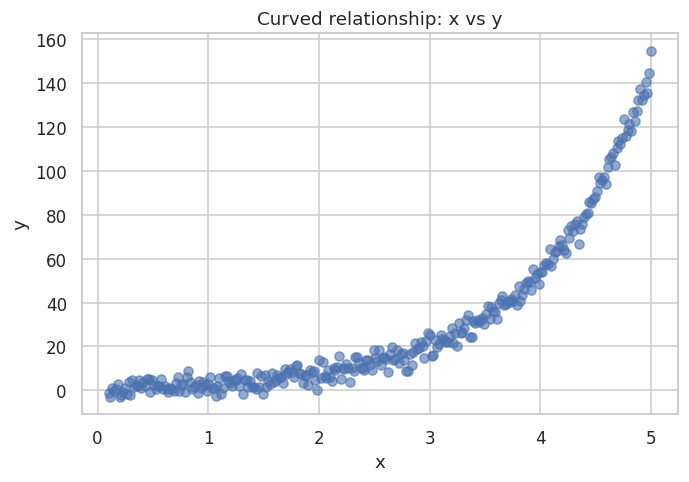

(b) color_intensity vs hue
{'pearson': -0.5218131932287577, 'spearman': -0.4185217619000421, 'difference': -0.10329143132871565}


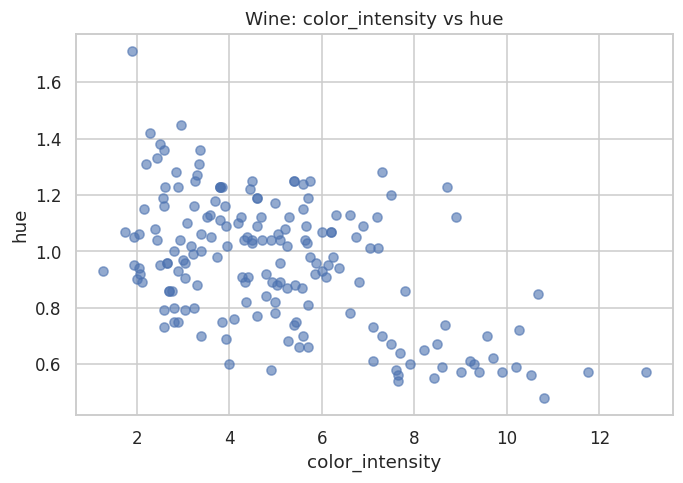

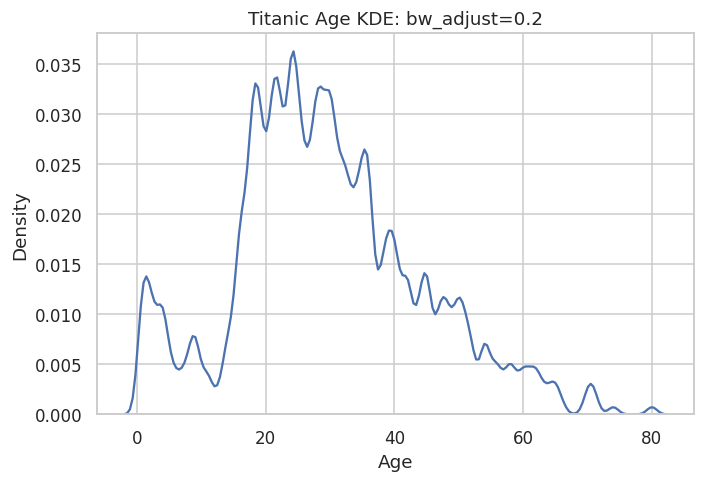

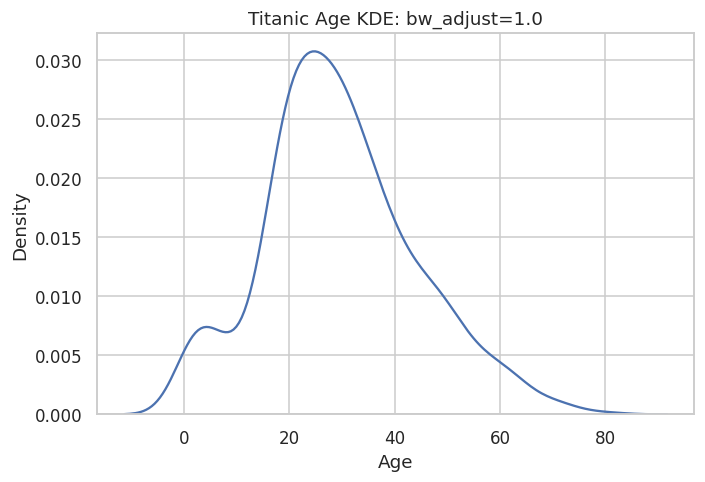

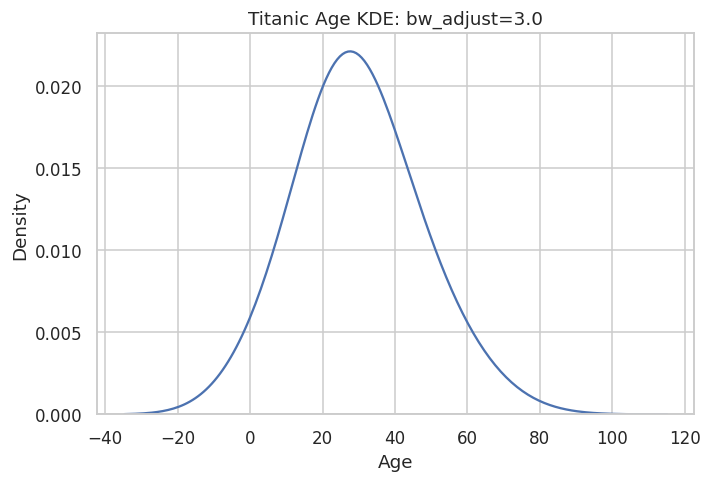

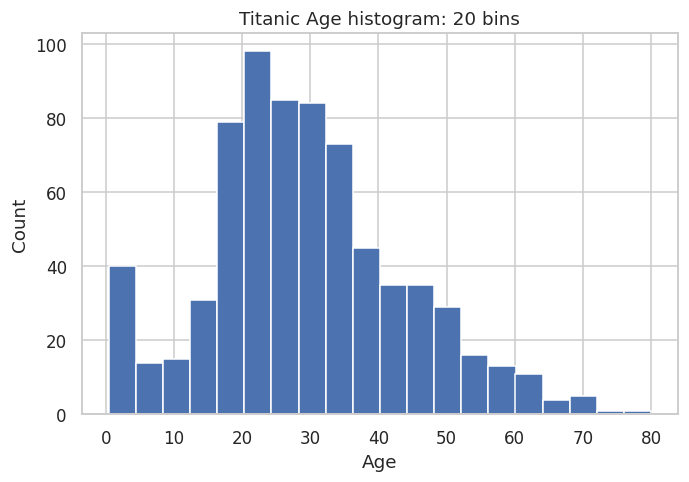

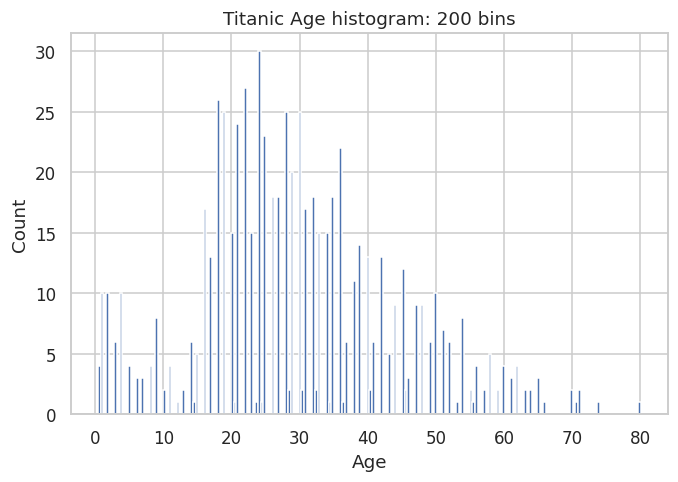

In [ ]:
# (a) Curved pair
curved_result = correlation_pair(_curved, "x", "y")

print("(a) Curved pair")
print(curved_result)

plt.figure()
plt.scatter(_curved["x"], _curved["y"], alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curved relationship: x vs y")
plt.show()


# (b) Wine: color_intensity vs hue
wine_result = correlation_pair(wine, "color_intensity", "hue")

print("(b) color_intensity vs hue")
print(wine_result)

plt.figure()
plt.scatter(wine["color_intensity"], wine["hue"], alpha=0.6)
plt.xlabel("color_intensity")
plt.ylabel("hue")
plt.title("Wine: color_intensity vs hue")
plt.show()


# (c) Titanic Age — KDE
age = titanic["Age"].dropna()

for bw in [0.2, 1.0, 3.0]:
    plt.figure()
    sns.kdeplot(x=age, bw_adjust=bw)
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.title(f"Titanic Age KDE: bw_adjust={bw}")
    plt.show()


# Titanic Age — histograms
for bins in [20, 200]:
    plt.figure()
    plt.hist(age, bins=bins)
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.title(f"Titanic Age histogram: {bins} bins")
    plt.show()

**Your answer:**

(a) For the curved pair, Pearson correlation is approximately 0.8605 and Spearman correlation is approximately 0.9653, so they differ by about 0.10. Pearson measures linear association, while Spearman measures monotonic association based on ranks. The scatter plot shows a strong increasing but clearly nonlinear relationship, which is why Spearman is higher: the ordering is very consistent even though the points do not follow a straight line. If I were going to fit a linear model, I would report Pearson because it measures the linear association that is directly relevant to a linear model.

(b) For color_intensity and hue, Pearson is approximately -0.5218 and Spearman is approximately -0.4185. The scatter plot shows an overall negative relationship, but it is not a clean linear or uniformly monotonic pattern. The distribution contains clusters and uneven spread, particularly at higher color intensity values, so Pearson and Spearman respond differently to the structure of the data.

(c) The histogram bin count and the KDE bandwidth both control the amount of smoothing and therefore the level of detail visible in the estimated distribution. A small KDE bandwidth or a very large number of histogram bins shows much more local detail, but it can create apparent peaks caused by sampling noise or measurement resolution. A large bandwidth or too few bins smooths the distribution strongly and can hide real structure. In these plots, bw_adjust=0.2 produces many small peaks, while bw_adjust=3.0 smooths most of them away. The 200-bin histogram similarly appears much more irregular than the 20-bin histogram. One feature visible with bw_adjust=0.2 is the sequence of narrow peaks associated with ages being recorded at preferred/discrete values, especially whole-number ages. This is an artifact of age recording and measurement resolution rather than evidence that the passenger population naturally contains many separate age subgroups.

Overall, the smoothing choice involves a trade-off: too much smoothing can hide genuine structure, while too little smoothing can make noise or recording artifacts look like real structure.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [ ]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
        # Get distinct categories in alphabetical order
    categories = sorted(series.unique())

    # Label encoding: category -> 0, 1, 2, ...
    label_codes = {cat: i for i, cat in enumerate(categories)}

    rows = []
    index = []

    # Compare every unordered pair of distinct categories
    for i in range(len(categories)):
        for j in range(i + 1, len(categories)):
            a = categories[i]
            b = categories[j]

            # Distance under label encoding
            label_distance = abs(label_codes[a] - label_codes[b])

            # For one-hot encoding, any two different categories
            # differ in two positions: sqrt(1^2 + 1^2)
            onehot_distance = np.sqrt(2)

            rows.append({
                "label_distance": float(label_distance),
                "onehot_distance": float(onehot_distance)
            })

            index.append(f"{a}|{b}")

    result = pd.DataFrame(rows, index=index)

    return result.sort_index()

In [ ]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [ ]:
# Check how label encoding distances change after renaming categories

original = {"Cherbourg": 0, "Queenstown": 1, "Southampton": 2}
renamed = {"Queenstown": 0, "Southampton": 1, "Cherbourg": 2}

print("Original labels:", original)
print("C-Q distance:", abs(original["Cherbourg"] - original["Queenstown"]))
print("C-S distance:", abs(original["Cherbourg"] - original["Southampton"]))

print("\nAfter renaming/reordering:", renamed)
print("C-Q distance:", abs(renamed["Cherbourg"] - renamed["Queenstown"]))
print("C-S distance:", abs(renamed["Cherbourg"] - renamed["Southampton"]))
print("Q-S distance:", abs(renamed["Queenstown"] - renamed["Southampton"]))

Original labels: {'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2}
C-Q distance: 1
C-S distance: 2

After renaming/reordering: {'Queenstown': 0, 'Southampton': 1, 'Cherbourg': 2}
C-Q distance: 2
C-S distance: 1
Q-S distance: 1


**Your answer:**

(a) With the original label encoding, Cherbourg (C) and Southampton (S) are 2 units apart, while Cherbourg (C) and Queenstown (Q) are 1 unit apart. After renaming/reordering the categories alphabetically as Queenstown, Southampton, Cherbourg, the labels become Q=0, S=1, C=2. Therefore, C and Q are now 2 units apart, C and S are 1 unit apart, and Q and S are 1 unit apart. The geometry has changed even though the underlying categories have not. This shows that label encoding creates artificial distances: simply renaming or reordering categories can change a model's notion of which categories are similar.

(b) Pclass has a genuine ordered relationship: class 1, class 2, and class 3 represent an inherent ranking of passenger classes. Embarked has no inherent ordering: Cherbourg, Queenstown, and Southampton are simply different categories, and none is naturally greater or less than another. Therefore, integer encoding can meaningfully preserve the ordering of Pclass, but for Embarked it introduces an arbitrary order and artificial distances.

(c) Tree-based model families, such as decision trees and random forests, are relatively less sensitive to this distinction because they make predictions through threshold-based splits rather than directly using geometric distances between observations. However, arbitrary integer encoding of a nominal feature can still affect which category groupings are easy to represent, so one-hot encoding may still be preferable for unordered categories.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    # Fit ONLY on the training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Use the same fitted scaler for the test data
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }

In [ ]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

X = wine[_features].values
y = wine["target"].values

# Use exactly the same train/test split as Task 8
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

# (a) StandardScaler
standard = StandardScaler()
X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

# MinMaxScaler
minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

print("(a) TEST-SET RANGES")
print("StandardScaler:")
print("min =", X_test_std.min())
print("max =", X_test_std.max())

print("\nMinMaxScaler:")
print("min =", X_test_mm.min())
print("max =", X_test_mm.max())


# (b) Add one extreme proline value
proline_idx = _features.index("proline")

X_extreme = X_train.copy()

# Find the largest proline value in training data
row = np.argmax(X_extreme[:, proline_idx])

print("\n(b) EXTREME PROLINE")
print("original largest proline =", X_extreme[row, proline_idx])

# Multiply it by 50
X_extreme[row, proline_idx] *= 50

print("extreme proline =", X_extreme[row, proline_idx])

# Fit both scalers to original and contaminated training data
std_original = StandardScaler().fit(X_train)
std_extreme = StandardScaler().fit(X_extreme)

mm_original = MinMaxScaler().fit(X_train)
mm_extreme = MinMaxScaler().fit(X_extreme)

print("\nStandardScaler proline parameters:")
print("original mean =", std_original.mean_[proline_idx])
print("extreme mean  =", std_extreme.mean_[proline_idx])
print("original scale =", std_original.scale_[proline_idx])
print("extreme scale  =", std_extreme.scale_[proline_idx])

print("\nMinMaxScaler proline range:")
print("original min =", mm_original.data_min_[proline_idx])
print("original max =", mm_original.data_max_[proline_idx])
print("extreme min  =", mm_extreme.data_min_[proline_idx])
print("extreme max  =", mm_extreme.data_max_[proline_idx])

(a) TEST-SET RANGES
StandardScaler:
min = -2.5320938741135475
max = 4.757209616392293

MinMaxScaler:
min = -0.04363636363636364
max = 1.1358024691358026

(b) EXTREME PROLINE
original largest proline = 1680.0
extreme proline = 84000.0

StandardScaler proline parameters:
original mean = 753.008064516129
extreme mean  = 1416.8790322580646
original scale = 318.1152787593279
extreme scale  = 7452.592622697348

MinMaxScaler proline range:
original min = 290.0
original max = 1680.0
extreme min  = 290.0
extreme max  = 84000.0


**Your answer:**

(a) With StandardScaler, the transformed test set ranges from approximately -2.5322 to 4.7572. With MinMaxScaler, it ranges from approximately -0.0436 to 1.1358. The MinMaxScaler test values can fall outside [0, 1] because the scaler is fitted only on the training set. If a test value is smaller than the training minimum or larger than the training maximum, its transformed value will be below 0 or above 1. This is correct behaviour and avoids data leakage because information from the test set is not used when fitting the scaler.

(b) After multiplying the largest proline value by 50, it increases from 1680 to 84000. For StandardScaler, the mean changes from about 753.01 to 1416.88, while the scale increases from about 318.12 to 7452.59. For MinMaxScaler, the minimum remains 290, but the maximum increases from 1680 to 84000. Both scalers are sensitive to the extreme value, but MinMaxScaler is especially disturbed because it directly uses the minimum and maximum to define the scale. The extreme maximum greatly expands the range and compresses the ordinary observations into a very small part of the [0, 1] interval. StandardScaler is also affected because the outlier increases both the mean and standard deviation.

(c) If a leaked scaler produces higher test accuracy, that extra accuracy is partly measuring the benefit of having information about the test set available during training rather than true generalisation to unseen data. When the scaler is fitted before the train/test split, test-set information contributes to the scaling parameters: the mean and standard deviation for StandardScaler or the minimum and maximum for MinMaxScaler. Therefore, information about the distribution of the test data has crossed into the training procedure, making the reported test accuracy optimistically biased.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [ ]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    if standardise:
        scaler = StandardScaler()
        X_used = scaler.fit_transform(X)
    else:
        X_used = X

    # Fit PCA using all components
    pca = PCA(random_state=SEED)
    pca.fit(X_used)

    # Cumulative explained variance
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    # Find the smallest number of components needed for each threshold
    needed = {}

    for threshold in thresholds:
        needed[threshold] = int(np.searchsorted(cumulative, threshold) + 1)

    return {
        "cumulative": cumulative,
        "needed": needed
    }

In [ ]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

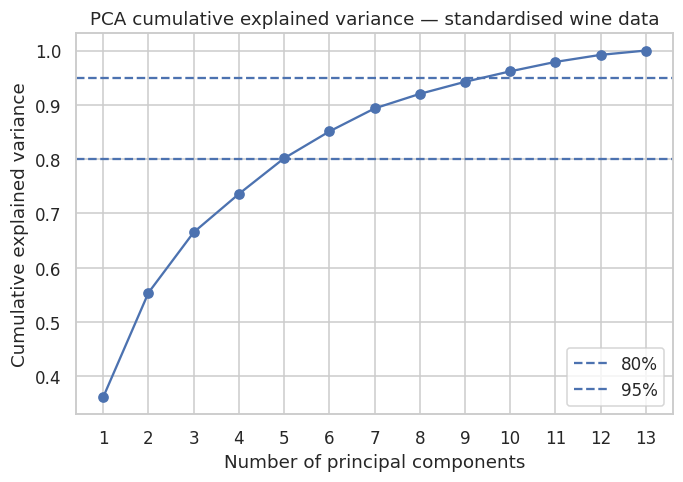

Components needed:
80%: 5
95%: 10

Largest absolute PC1 loadings (unstandardised):
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047
color_intensity     0.0023
alcohol             0.0017
dtype: float64


In [ ]:
# Question 6 — supporting analysis

X_wine = wine[_features].values

# Standardised PCA
scaled_result = components_for_variance(
    X_wine,
    thresholds=(0.5, 0.8, 0.95, 0.99),
    standardise=True
)

cumulative = scaled_result["cumulative"]

# Plot cumulative explained variance
plt.figure(figsize=(7, 4.5))
plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance — standardised wine data")
plt.xticks(range(1, len(cumulative) + 1))
plt.legend()
plt.show()

print("Components needed:")
print("80%:", scaled_result["needed"][0.8])
print("95%:", scaled_result["needed"][0.95])

# Check which feature dominates unstandardised PCA
pca_raw = PCA(random_state=SEED)
pca_raw.fit(X_wine)

pc1_loadings = pd.Series(
    np.abs(pca_raw.components_[0]),
    index=_features
).sort_values(ascending=False)

print("\nLargest absolute PC1 loadings (unstandardised):")
print(pc1_loadings.head())

**Your answer:**

(a) Without standardisation, the first principal component is essentially measuring proline. Proline has a much larger numerical scale and variance than most of the other wine features, so its variation dominates the covariance structure used by PCA. As a result, PCA “finds” a first component that is heavily aligned with proline and this component alone explains about 99.81% of the unstandardised variance. This shows that applying PCA directly to variables measured in different units can make features with large numerical scales dominate the result, even when they are not necessarily more important.

(b) For the standardised wine data, 5 components are needed to reach 80% cumulative explained variance, while 10 components are needed to reach 95%. Instead of selecting an arbitrary explained-variance threshold, I would treat the number of components as a model-selection hyperparameter. I would evaluate several values using cross-validation on the training data and measure performance using the metric relevant to the actual task, such as classification accuracy. I would then choose the smallest number of components that gives performance close to the best validated result, balancing predictive performance against dimensionality and complexity. The final choice should then be evaluated once on an untouched test set.

(c) Saying that “component 2 is the strongest predictor” means that the particular linear combination of the original wine measurements represented by PC2 has the strongest predictive relationship in that fitted model. However, it does not mean that one original wine measurement is the strongest predictor, because a principal component combines multiple original features with different loadings. To give a meaningful interpretation to a winemaker, I would need to inspect the PC2 loadings to determine which original measurements contribute most strongly and in which directions. Even then, predictive importance does not by itself establish that changing those measurements would cause a change in the outcome.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [ ]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    # 1. Standardise X
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA reduction to n_pca components
    pca_reducer = PCA(n_components=n_pca, random_state=seed)
    reduced = pca_reducer.fit_transform(X_scaled)

    # 3. t-SNE on the PCA-reduced data
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Separate PCA with exactly 2 components
    pca_2 = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2.fit_transform(X_scaled)

    # Fraction of variance explained by the first two PCs
    explained_2d = float(pca_2.explained_variance_ratio_.sum())

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced
    }

In [ ]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# mnist = pd.read_csv("../datasets/mnist_sample.csv")
# digit_labels = mnist["label"].values
# pixels = mnist.drop(columns="label").values

# print("pixels", pixels.shape, " labels", digit_labels.shape)
# print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# _small = pixels[:300]
# _projection = project_two_ways(_small, perplexity=30, seed=SEED)

In [ ]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

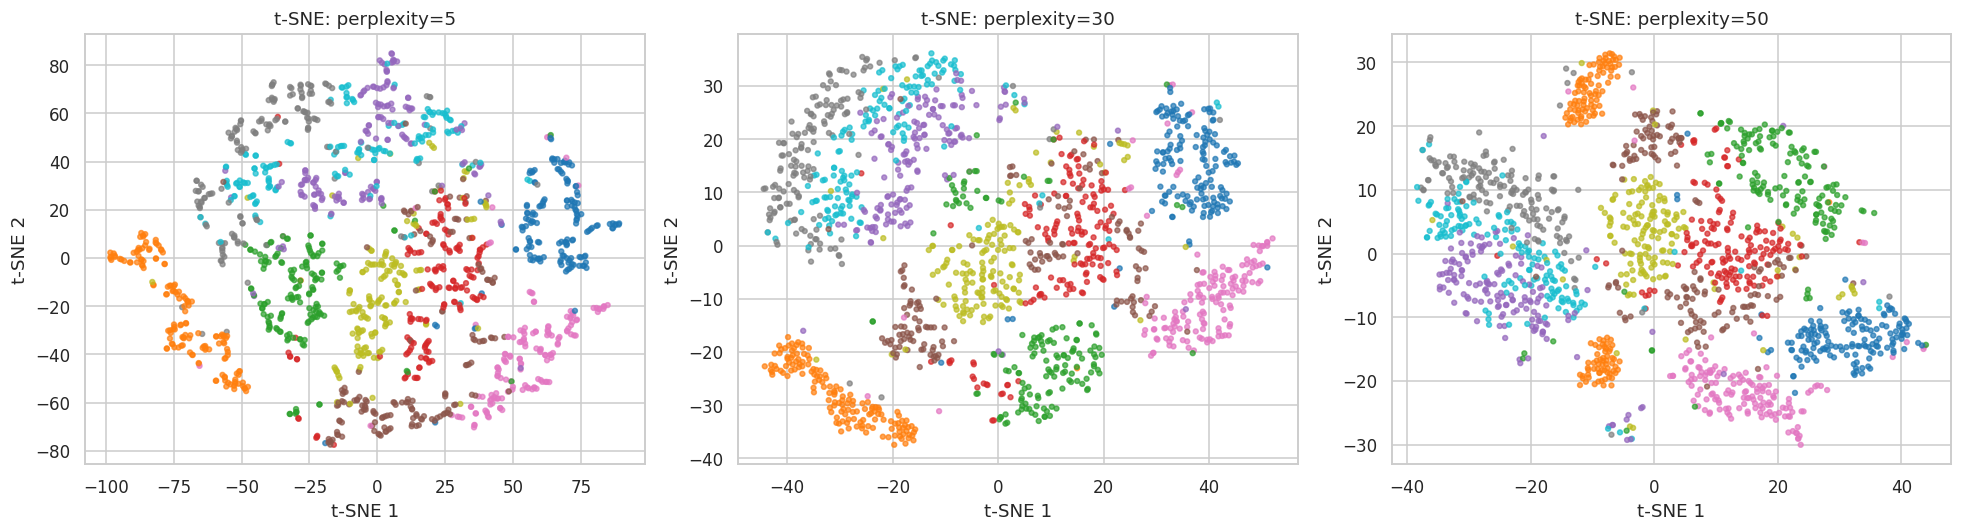

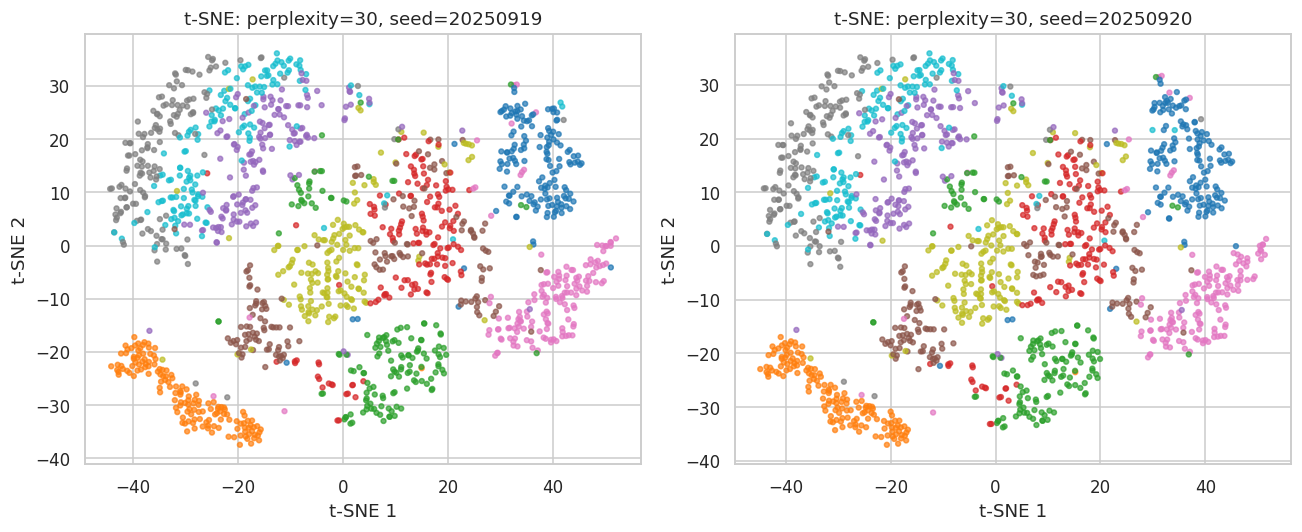

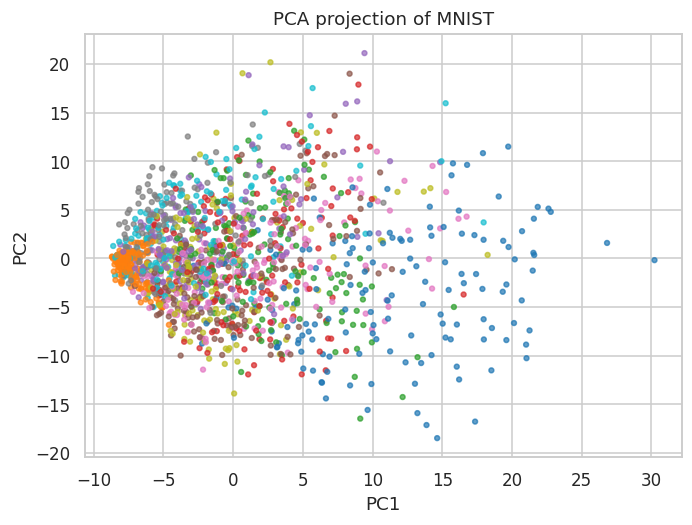

Variance explained by first two PCs: 0.11630289433429974


In [ ]:
# Question 7 — perplexity and seed

# Standardise the full 1500-row MNIST sample
X_scaled = StandardScaler().fit_transform(pixels)

# Reduce dimensionality before t-SNE
pca50 = PCA(n_components=50, random_state=SEED)
X_reduced = pca50.fit_transform(X_scaled)

# (a) Three perplexities with the same seed
perplexities = [5, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, perplexities):
    embedding = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=SEED,
        init="pca"
    ).fit_transform(X_reduced)

    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=digit_labels,
        cmap="tab10",
        s=10,
        alpha=0.7
    )

    ax.set_title(f"t-SNE: perplexity={perp}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# (b) Same perplexity, two different seeds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, seed in zip(axes, [SEED, SEED + 1]):
    embedding = TSNE(
        n_components=2,
        perplexity=30,
        random_state=seed,
        init="pca"
    ).fit_transform(X_reduced)

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=digit_labels,
        cmap="tab10",
        s=10,
        alpha=0.7
    )

    ax.set_title(f"t-SNE: perplexity=30, seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# (c) PCA projection for comparison
pca2 = PCA(n_components=2, random_state=SEED)
pca_2d_full = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_2d_full[:, 0],
    pca_2d_full[:, 1],
    c=digit_labels,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of MNIST")
plt.show()

print(
    "Variance explained by first two PCs:",
    pca2.explained_variance_ratio_.sum()
)

**Your answer:**

(a) The three t-SNE projections show that perplexity changes the balance between local and broader neighbourhood structure. At perplexity = 5, t-SNE focuses on relatively small local neighbourhoods, and several digit classes are more fragmented into separate small groups. At perplexity = 30, the clusters become more coherent while still preserving good separation between many digit classes. At perplexity = 50, broader neighbourhood relationships receive more weight and some groups become more compact or merge more strongly. Thus, perplexity can be interpreted roughly as controlling the effective number of neighbours each point tries to stay close to. In these projections, low perplexity produces more fragmented local groups, while higher perplexity gives greater weight to broader neighbourhood structure and makes some classes appear more compact or more strongly merged.

(b) The two runs with perplexity = 30 and different random seeds are similar in their local grouping, but their exact positions, orientations and shapes are not identical. t-SNE is seed-dependent because its optimisation is stochastic and the non-convex objective can lead to different two-dimensional arrangements. Therefore, a published t-SNE figure without a stated random_state is not fully reproducible, and the exact global arrangement of its clusters should not be treated as a unique solution.

(c) t-SNE separates the digit classes much more clearly than the two-dimensional PCA projection. The first two PCA components explain only about 11.63% of the total variance, and the PCA plot shows substantial overlap between the digit classes. However, from a t-SNE plot I still cannot conclude that distances between separate clusters represent meaningful original-space distances, that the relative sizes or densities of clusters are quantitatively meaningful, or that apparent gaps necessarily prove the existence of genuinely separate groups in the original 784-dimensional space. For input to a clustering algorithm I would use PCA rather than the two-dimensional t-SNE embedding. PCA provides a deterministic linear transformation, preserves more interpretable global geometry, and can transform new observations, whereas t-SNE is primarily a visualization method whose geometry depends on parameters and random initialization.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [ ]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    # Create a figure with two panels
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ----- LEFT PANEL: working day vs non-working day -----

    working_profiles = (
        bikes_frame
        .groupby(["workingday", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    working_labels = {
        0: "Non-working day",
        1: "Working day"
    }

    for workingday, group in working_profiles.groupby("workingday"):
        axes[0].plot(
            group["hr"],
            group["cnt"],
            label=working_labels[workingday]
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean bicycle demand")
    axes[0].set_title("Daily demand: working vs non-working days")
    axes[0].legend()


    # ----- RIGHT PANEL: weather situation -----

    weather_profiles = (
        bikes_frame
        .groupby(["weathersit", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    for weather, group in weather_profiles.groupby("weathersit"):
        axes[1].plot(
            group["hr"],
            group["cnt"],
            label=f"Weather {weather}"
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean bicycle demand")
    axes[1].set_title("Daily demand by weather")
    axes[1].legend()


    # Figure title
    fig.suptitle(
        "Hourly bicycle demand by working day and weather"
    )

    fig.tight_layout()

    return fig, axes

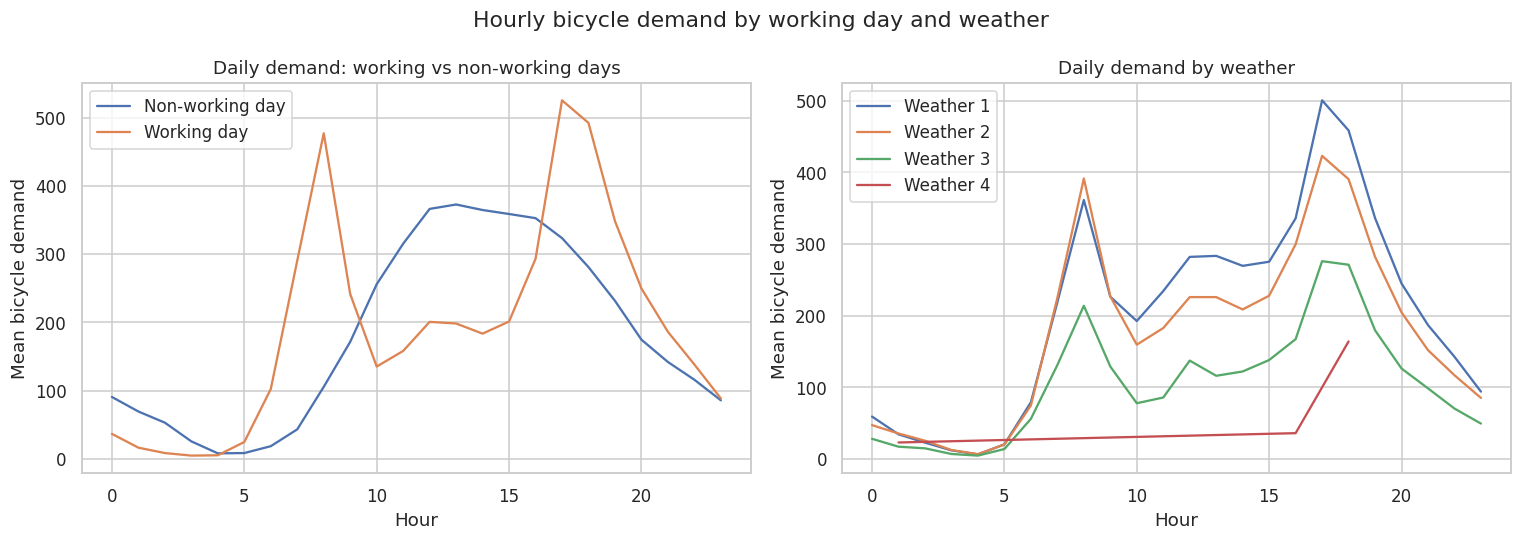

Task 11 passed.


In [ ]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

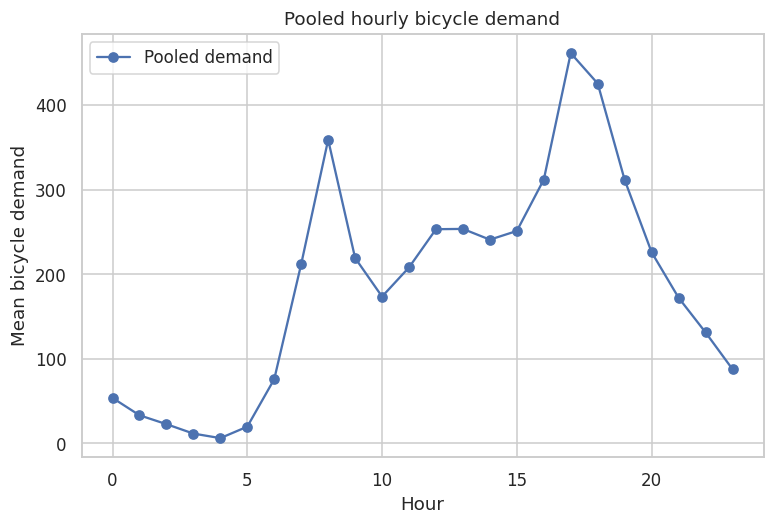

In [ ]:
# Pooled hourly demand profile
pooled = (
    bikes
    .groupby("hr")["cnt"]
    .mean()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    pooled.index,
    pooled.values,
    marker="o",
    label="Pooled demand"
)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean bicycle demand")
ax.set_title("Pooled hourly bicycle demand")
ax.legend()

plt.show()

**Your answer:**

(a) The pooled profile shows two clear peaks, around 8:00 and 17:00, which could suggest that bicycle demand generally follows a morning-and-evening commuter pattern. However, this is misleading because the two underlying groups have different profiles. Working days have strong commuting peaks, especially around 8:00 and 17:00–18:00, while non-working days do not have the same morning rush-hour pattern and instead have a broader daytime peak. Therefore, the pooled profile creates a pattern that is not representative of both groups individually.

(b) This is an example of Simpson's paradox, or more generally an aggregation effect. A pattern observed in aggregated data can change, disappear, or become misleading when the data are conditioned on an important grouping variable. The general rule is that an aggregate should not be interpreted without checking relevant subgroups, because differences between groups can create or hide important patterns.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [ ]:
# TASK 12 — Data quality and structure report

# Basic structure
print("Shape:", bikes.shape)

print("\nCOLUMN TYPES:")
print(bikes.dtypes)

print("\nFIRST 5 ROWS:")
display(bikes.head())

print("\nMISSING VALUES:")
print(bikes.isna().sum())

print("\nUNIQUE VALUES:")
for col in bikes.columns:
    print(col, ":", bikes[col].nunique())


# Integer-coded categorical columns
categorical_cols = ["season", "yr", "mnth", "hr",
                    "holiday", "weekday", "workingday",
                    "weathersit"]

print("\nCATEGORICAL VALUES:")
for col in categorical_cols:
    print(col, sorted(bikes[col].unique()))


# Columns stored as numbers but representing categories
bikes_fixed = bikes.copy()

for col in categorical_cols:
    bikes_fixed[col] = bikes_fixed[col].astype("category")

# Parse date
bikes_fixed["dteday"] = pd.to_datetime(bikes_fixed["dteday"])

print("\nTYPES AFTER FIX:")
print(bikes_fixed.dtypes)


# Demonstrate that a meaningless numeric operation is now rejected
print("\nMEANINGLESS OPERATION TEST:")

try:
    print(bikes_fixed["season"].mean())
except Exception as e:
    print("season.mean() now gives an error:")
    print(type(e).__name__, "-", e)

Shape: (17379, 17)

COLUMN TYPES:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

FIRST 5 ROWS:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1



MISSING VALUES:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

UNIQUE VALUES:
instant : 17379
dteday : 731
season : 4
yr : 2
mnth : 12
hr : 24
holiday : 2
weekday : 7
workingday : 2
weathersit : 4
temp : 50
atemp : 65
hum : 89
windspeed : 30
casual : 322
registered : 776
cnt : 869

CATEGORICAL VALUES:
season [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr [np.int64(0), np.int64(1)]
mnth [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hr [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)

In [ ]:
# Restore physical units

physical = bikes.copy()

physical["temp_C"] = physical["temp"] * 41
physical["atemp_C"] = physical["atemp"] * 50
physical["humidity_pct"] = physical["hum"] * 100
physical["windspeed_kmh"] = physical["windspeed"] * 67

cols = [
    "temp_C",
    "atemp_C",
    "humidity_pct",
    "windspeed_kmh"
]

print("RESTORED PHYSICAL UNITS:")
print(physical[cols].agg(["min", "max", "mean"]).round(2))

RESTORED PHYSICAL UNITS:
      temp_C  atemp_C  humidity_pct  windspeed_kmh
min   0.8200   0.0000        0.0000         0.0000
max  41.0000  50.0000      100.0000        57.0000
mean 20.3800  23.7900       62.7200        12.7400


In [ ]:
# STEP 3 — Check date and hourly completeness

dates = pd.to_datetime(bikes["dteday"])

print("DATE RANGE:")
print("Start:", dates.min())
print("End:  ", dates.max())

print("\nUnique days:", dates.nunique())
print("Actual rows:", len(bikes))

# Number of observed hours for every day
hours_per_day = (
    bikes.assign(dteday_parsed=dates)
         .groupby("dteday_parsed")["hr"]
         .nunique()
)

expected_rows = dates.nunique() * 24
missing_rows = expected_rows - len(bikes)

print("\nExpected rows if every observed day had 24 hours:", expected_rows)
print("Missing hourly rows:", missing_rows)

print("\nNUMBER OF DAYS BY HOURS RECORDED:")
print(hours_per_day.value_counts().sort_index())

incomplete_days = hours_per_day[hours_per_day < 24]

print("\nINCOMPLETE DAYS:")
print("Number of incomplete days:", len(incomplete_days))
print(incomplete_days)

DATE RANGE:
Start: 2011-01-01 00:00:00
End:   2012-12-31 00:00:00

Unique days: 731
Actual rows: 17379

Expected rows if every observed day had 24 hours: 17544
Missing hourly rows: 165

NUMBER OF DAYS BY HOURS RECORDED:
hr
1       1
8       1
11      1
12      1
16      1
17      1
18      2
22      6
23     62
24    655
Name: count, dtype: int64

INCOMPLETE DAYS:
Number of incomplete days: 76
dteday_parsed
2011-01-02    23
2011-01-03    22
2011-01-04    23
2011-01-05    23
2011-01-06    23
              ..
2012-10-30    11
2012-11-08    23
2012-11-29    23
2012-12-24    23
2012-12-25    23
Name: hr, Length: 76, dtype: int64


In [ ]:
# STEP 3.1 — Find exactly which hours are missing

all_hours = set(range(24))

missing_records = []

for date, group in bikes.groupby(pd.to_datetime(bikes["dteday"])):
    observed = set(group["hr"])
    missing = sorted(all_hours - observed)

    for hour in missing:
        missing_records.append({
            "date": date,
            "hour": hour
        })

missing_hours = pd.DataFrame(missing_records)

print("TOTAL MISSING HOURS:")
print(len(missing_hours))

print("\nMISSING HOURS BY HOUR OF DAY:")
print(
    missing_hours["hour"]
    .value_counts()
    .sort_index()
)

print("\nFIRST 30 MISSING OBSERVATIONS:")
print(missing_hours.head(30))

TOTAL MISSING HOURS:
165

MISSING HOURS BY HOUR OF DAY:
hour
0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3
Name: count, dtype: int64

FIRST 30 MISSING OBSERVATIONS:
         date  hour
0  2011-01-02     5
1  2011-01-03     2
2  2011-01-03     3
3  2011-01-04     3
4  2011-01-05     3
5  2011-01-06     3
6  2011-01-07     3
7  2011-01-11     3
8  2011-01-11     4
9  2011-01-12     3
10 2011-01-12     4
11 2011-01-14     4
12 2011-01-18     0
13 2011-01-18     1
14 2011-01-18     2
15 2011-01-18     3
16 2011-01-18     4
17 2011-01-18     5
18 2011-01-18     6
19 2011-01-18     7
20 2011-01-18     8
21 2011-01-18     9
22 2011-01-18    10
23 2011-01-18    11
24 2011-01-19     3
25 2011-01-22     5
26 2011-01-23     4
27 2011-01-24     2
28 2011-01-25     3
29 2011-01-26     3


In [ ]:
# STEP 4 — Correlation matrix

numeric = bikes.select_dtypes(include="number")
corr = numeric.corr()

print("CORRELATION MATRIX:")
display(corr.round(2))

print("\nSELECTED CORRELATIONS:")

pairs = [
    ("season", "temp"),
    ("weekday", "cnt"),
    ("weathersit", "cnt"),
    ("casual", "cnt"),
    ("registered", "cnt"),
    ("temp", "atemp")
]

for a, b in pairs:
    print(
        f"{a:12s} vs {b:12s}: "
        f"{corr.loc[a, b]:.3f}"
    )

CORRELATION MATRIX:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.0000,0.4000,0.8700,0.4900,-0.0000,0.0100,0.0000,-0.0000,-0.0100,0.1400,0.1400,0.0100,-0.0700,0.1600,0.2800,0.2800
season,0.4000,1.0000,-0.0100,0.8300,-0.0100,-0.0100,-0.0000,0.0100,-0.0100,0.3100,0.3200,0.1500,-0.1500,0.1200,0.1700,0.1800
yr,0.8700,-0.0100,1.0000,-0.0100,-0.0000,0.0100,-0.0000,-0.0000,-0.0200,0.0400,0.0400,-0.0800,-0.0100,0.1400,0.2500,0.2500
mnth,0.4900,0.8300,-0.0100,1.0000,-0.0100,0.0200,0.0100,-0.0000,0.0100,0.2000,0.2100,0.1600,-0.1400,0.0700,0.1200,0.1200
hr,-0.0000,-0.0100,-0.0000,-0.0100,1.0000,0.0000,-0.0000,0.0000,-0.0200,0.1400,0.1300,-0.2800,0.1400,0.3000,0.3700,0.3900
holiday,0.0100,-0.0100,0.0100,0.0200,0.0000,1.0000,-0.1000,-0.2500,-0.0200,-0.0300,-0.0300,-0.0100,0.0000,0.0300,-0.0500,-0.0300
weekday,0.0000,-0.0000,-0.0000,0.0100,-0.0000,-0.1000,1.0000,0.0400,0.0000,-0.0000,-0.0100,-0.0400,0.0100,0.0300,0.0200,0.0300
workingday,-0.0000,0.0100,-0.0000,-0.0000,0.0000,-0.2500,0.0400,1.0000,0.0400,0.0600,0.0500,0.0200,-0.0100,-0.3000,0.1300,0.0300
weathersit,-0.0100,-0.0100,-0.0200,0.0100,-0.0200,-0.0200,0.0000,0.0400,1.0000,-0.1000,-0.1100,0.4200,0.0300,-0.1500,-0.1200,-0.1400
temp,0.1400,0.3100,0.0400,0.2000,0.1400,-0.0300,-0.0000,0.0600,-0.1000,1.0000,0.9900,-0.0700,-0.0200,0.4600,0.3400,0.4000



SELECTED CORRELATIONS:
season       vs temp        : 0.312
weekday      vs cnt         : 0.027
weathersit   vs cnt         : -0.142
casual       vs cnt         : 0.695
registered   vs cnt         : 0.972
temp         vs atemp       : 0.988


In [ ]:
# STEP 5 — Check target leakage

difference = (
    bikes["casual"] +
    bikes["registered"] -
    bikes["cnt"]
)

print("TARGET LEAKAGE CHECK:")
print(
    "casual + registered == cnt for every row:",
    (difference == 0).all()
)

print(
    "Maximum absolute difference:",
    difference.abs().max()
)

print("\nCORRELATIONS WITH TARGET:")
print(
    bikes[["casual", "registered", "cnt"]]
    .corr()
    .round(3)
)

TARGET LEAKAGE CHECK:
casual + registered == cnt for every row: True
Maximum absolute difference: 0

CORRELATIONS WITH TARGET:
            casual  registered    cnt
casual      1.0000      0.5070 0.6950
registered  0.5070      1.0000 0.9720
cnt         0.6950      0.9720 1.0000


In [ ]:
# STEP 6 — Recommended feature set for hourly demand prediction

target = "cnt"

# Variables that must not be given directly to the model
excluded = [
    "instant",       # row identifier
    "dteday",        # raw date; useful information should be extracted first
    "casual",        # target leakage
    "registered",    # target leakage
    "cnt"            # target itself
]

features = [
    c for c in bikes.columns
    if c not in excluded
]

categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

print("TARGET:")
print(target)

print("\nFEATURES TO USE:")
print(features)

print("\nCATEGORICAL FEATURES:")
print(categorical_features)

print("\nNUMERIC FEATURES:")
print(numeric_features)

print("\nEXCLUDED:")
print(excluded)

print("\nNumber of model features:", len(features))

TARGET:
cnt

FEATURES TO USE:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

CATEGORICAL FEATURES:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

NUMERIC FEATURES:
['temp', 'atemp', 'hum', 'windspeed']

EXCLUDED:
['instant', 'dteday', 'casual', 'registered', 'cnt']

Number of model features: 12


**Your write-up:**

1. Types.
Several columns are stored as integers even though they represent categories rather than quantities. These include season, yr, mnth, hr, holiday, weekday, workingday, and weathersit. Treating them as ordinary numbers permits meaningless operations such as calculating the mean of season. I converted these variables to categorical variables and parsed dteday as a datetime. After this correction, an operation such as season.mean() produces an error, which is appropriate because averaging season labels has no meaningful interpretation.

2. Units.
The four normalized physical measurements were converted back to their original units. The observed ranges are approximately 0.82–41.0°C for temperature, 0–50.0°C for apparent temperature, 0–100% for humidity, and 0–57 km/h for wind speed. These ranges are generally plausible for Washington, D.C. The temperature and humidity values appear reasonable. The maximum wind speed is relatively high but still physically possible. Therefore, there is no obvious impossible value that would require removing observations solely on the basis of these ranges.

3. The date.
After parsing dteday, the data cover 731 unique days from 2011-01-01 through 2012-12-31. If every observed day contained all 24 hourly observations, there would be 17,544 rows, but the dataset contains 17,379 rows. Therefore, 165 hourly observations are missing, spread across 76 incomplete days. The missingness is not completely random: many days contain 23 observations, while some have larger blocks of missing hours. For example, several missing observations occur in neighbouring hours on the same dates. This structure should be considered in time-based analyses rather than treating the dataset as a perfectly complete hourly series.

4. Correlations that should not be computed or interpreted literally.
A correlation matrix can be calculated numerically, but some entries are meaningless or misleading. For example, season versus temp has a correlation of about 0.312, but season is an integer-coded category, so its numerical spacing and ordering should not be interpreted as a continuous quantitative scale. Similarly, correlations involving variables such as weekday can be misleading: weekday versus cnt is about 0.027, but the numerical codes assigned to weekdays do not represent meaningful distances. Another example is temp versus atemp, with correlation about 0.988. This correlation is mathematically valid, but the variables measure almost the same underlying physical concept, so including both can introduce strong redundancy or multicollinearity.

5. Leakage.
casual and registered must not be used as predictors when predicting cnt, because

casual + registered = cnt

for every row in the dataset. The check produced a maximum absolute difference of 0. Their correlations with cnt are consequently very high (casual: about 0.695, registered: about 0.972), but this does not make them legitimate predictive features. Using them would leak information about the target directly into the model. They could legitimately be used in a different prediction task where these counts are already known at prediction time—for example, predicting another operational quantity after the hourly casual and registered counts have been observed.

6. Recommendation.
For a model predicting hourly bicycle demand (cnt), I would use season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, and windspeed, with the categorical variables encoded appropriately. I would exclude instant because it is a row identifier, exclude raw dteday from direct modelling while using it to derive meaningful time features if needed, exclude casual and registered because they cause target leakage, and exclude cnt from the predictors because it is the target itself. The most important modelling decisions are therefore to encode categorical variables appropriately, account for the structure of the missing hourly observations, avoid interpreting arbitrary category codes quantitatively, and prevent leakage from casual and registered.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.